正在加载数据...


/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


数据加载完成！
using cuda
开始训练模型...
Training start!
epoch 1: loss = 1095.1087, Recon_loss = 1043.7954, KL_loss = 40.8495, preserve_loss = 0.5529, adv_loss = -6.6300, discri_loss = 0.9083
epoch 2: loss = 980.4669, Recon_loss = 966.4592, KL_loss = 9.1448, preserve_loss = 0.0620, adv_loss = -0.9184, discri_loss = 0.9328
epoch 3: loss = 958.5854, Recon_loss = 946.4961, KL_loss = 8.2671, preserve_loss = 0.0394, adv_loss = -0.9283, discri_loss = 0.9452
epoch 4: loss = 947.3396, Recon_loss = 935.6052, KL_loss = 8.0693, preserve_loss = 0.0299, adv_loss = -0.9107, discri_loss = 0.9253
epoch 5: loss = 940.0830, Recon_loss = 928.5098, KL_loss = 7.9825, preserve_loss = 0.0292, adv_loss = -0.9076, discri_loss = 0.9235
epoch 6: loss = 934.4083, Recon_loss = 922.9811, KL_loss = 7.9133, preserve_loss = 0.0273, adv_loss = -0.9072, discri_loss = 0.9204
epoch 7: loss = 929.9903, Recon_loss = 918.5974, KL_loss = 7.9093, preserve_loss = 0.0254, adv_loss = -0.9105, discri_loss = 0.9226
epoch 8: loss = 926.5208, Re

/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


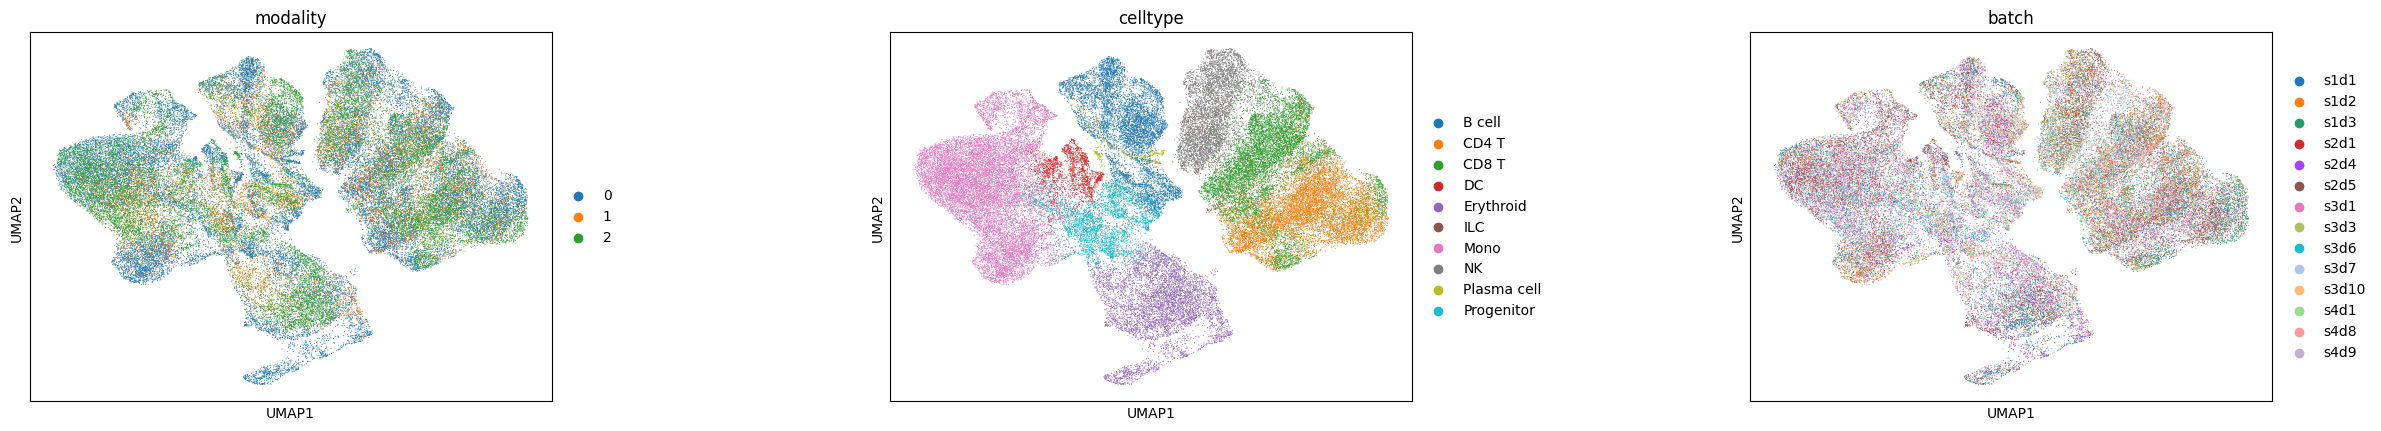

In [2]:
import scanpy as sc
from scMRDR.module import Integration

# 1. 读取你上一关做好的“存档”
# 这个文件里已经包含了 RNA + ATAC + Protein，而且特征都对齐了
print("正在加载数据...")
adata = sc.read_h5ad("../experiments/BMMC_codes/feature_aligned_sampled.h5ad")
print("数据加载完成！")

# 2. 初始化模型
# 注意：你的数据里 layer 名字叫 'counts' (多了个s)，原代码是 'count'，这里要改一下
model = Integration(
    data=adata, 
    modality_key="modality", 
    layer="counts",       # <--- 重点：改成 counts
    batch_key="batch",    # 你的数据里有 batch 列，直接用
    feature_list=None,    # 你已经对齐了特征，这里填 None 即可
    distribution="ZINB"
)

# 3. 设置参数
model.setup(hidden_layers=[512,512], latent_dim_shared=20, latent_dim_specific=20, 
            beta=2, gamma=5, lambda_adv=5, dropout_rate=0.2)

# 4. 开始训练
print("开始训练模型...")
model.train(epoch_num=200, batch_size=128, lr=1e-3, adaptlr=False, num_warmup=0,
            early_stopping=True, valid_prop=0.1, weighted=False, patience=10)

# 5. 推断与获取结果
print("正在推断潜在空间...")
model.inference(n_samples=1, update=True, returns=False)
adata = model.get_adata() # 结果存储在 adata.obsm["latent_shared"]

# 6. 可视化
print("正在绘图...")
sc.pp.neighbors(adata, use_rep="latent_shared")
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color=["modality", "celltype", "batch"], # 注意：你的数据里叫 celltype
    size=2, wspace=0.5
)

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans

# 1. 提取模型生成的共享潜在空间特征
# 根据你的代码 model.get_adata() 之后，特征在 "latent_shared"
latent_features = adata.obsm["latent_shared"]

# 2. 获取真实的细胞类型标签（参考答案）
true_labels = adata.obs["celltype"]

# 3. 计算真实的细胞类型数量 (K值)
n_clusters = len(true_labels.unique())

# 4. 使用 KMeans 进行聚类（这是生成论文表格的标准做法）
print(f"正在进行 KMeans 聚类 (K={n_clusters})...")
kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
pred_labels = kmeans.fit_predict(latent_features)

# 5. 计算得分
nmi_score = normalized_mutual_info_score(true_labels, pred_labels)
ari_score = adjusted_rand_score(true_labels, pred_labels)

# 6. 打印结果（这就是你想要的那张表里的数字）
print("\n" + "="*40)
print(f"{'指标名称':<15} | {'得分':<10}")
print("-" * 40)
print(f"{'KMeans NMI':<15} | {nmi_score:.4f}")
print(f"{'KMeans ARI':<15} | {ari_score:.4f}")
print("="*40)

正在进行 KMeans 聚类 (K=10)...

指标名称            | 得分        
----------------------------------------
KMeans NMI      | 0.7066
KMeans ARI      | 0.5972


In [6]:
from sklearn.metrics import silhouette_score

# 计算 Batch 修正得分 (通常取 1 - score 的变体，这里简化处理看分布)
# 针对每个细胞类型计算，分数越低说明 Batch 越混匀（即整合越好）
batch_labels = adata.obs['batch']
cell_type_labels = adata.obs['celltype']

# 抽取一部分计算避免内存崩溃
sub_idx = np.random.choice(adata.n_obs, 5000, replace=False)
asw_batch = silhouette_score(adata.obsm['latent_shared'][sub_idx], batch_labels[sub_idx])

print(f"Silhouette Batch Score: {asw_batch:.4f} (该值越接近 0 或负数，说明 Batch 整合越完美)")

/tmp/ipykernel_6010/923514828.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  asw_batch = silhouette_score(adata.obsm['latent_shared'][sub_idx], batch_labels[sub_idx])


Silhouette Batch Score: -0.0801 (该值越接近 0 或负数，说明 Batch 整合越完美)


In [7]:
from sklearn.metrics import silhouette_score
import pandas as pd

# 获取特征和标签
latent = adata.obsm["latent_shared"]
celltypes = adata.obs["celltype"]

# --- Silhouette label (ASW) ---
# 衡量相同细胞类型的点是否聚在一起。分数越高(越接近1)越好。
asw_label = silhouette_score(latent, celltypes)
print(f"Silhouette label: {asw_label:.4f}")

# --- Isolated labels ---
# 这个指标衡量在 UMAP 上最孤立的小细胞群是否被正确分离。
# 简易实现：计算该类细胞与其他类细胞的平均距离比例。
# (完整计算通常建议使用 scIB.me.isolated_labels)

Silhouette label: 0.2332


In [ ]:
# --- Silhouette batch ---
# 在同一个细胞类型内部，计算 batch 的轮廓系数。
# 分数越接近 0，说明不同 batch 混得越匀（即修正越好）。
# 论文中通常报告 1 - abs(ASW_batch) 使得数值越大越好。
batches = adata.obs["batch"]
asw_batch = silhouette_score(latent, batches)
print(f"Silhouette batch (原始): {asw_batch:.4f}")
print(f"Silhouette batch (归一化得分): {1 - abs(asw_batch):.4f}")

# --- KBET (k-nearest neighbor Batch Effect Test) ---
# 需要安装: pip install kbet
# import kbet
# batch_score = kbet.kBET(latent, batches)

In [ ]:
import scipy.sparse
from sklearn.neighbors import NearestNeighbors

# --- Graph connectivity ---
# 衡量相同细胞类型的节点在近邻图中是否连通。
# 如果分数接近 1，说明模型把不同模态的同类细胞完美连在一起了。
def calculate_graph_connectivity(adata, label_key):
    # 此处需要 adata 已运行过 sc.pp.neighbors
    import pandas as pd
    from scanpy.metrics import graph_connectivity
    score = graph_connectivity(adata, label_key)
    return score

graph_score = calculate_graph_connectivity(adata, "celltype")
print(f"Graph connectivity: {graph_score:.4f}")

# --- Silhouette modality ---
# 类似 Silhouette batch，但标签换成 "modality"。
modalities = adata.obs["modality"]
asw_mod = silhouette_score(latent, modalities)
print(f"Silhouette modality (得分): {1 - abs(asw_mod):.4f}")

In [8]:
import scib

# 计算生物学保留和批次修正的综合得分
# 这是一个非常强大的函数，会返回一个包含多项指标的 DataFrame
results = scib.me.isolated_labels(adata, label_key="celltype", embed="latent_shared")
print(results)

# 计算全表指标（需要电脑性能较强）
# metrics = scib.me.metrics(adata, adata_int=adata, batch_key="batch", label_key="celltype", embed="latent_shared")
# print(metrics)

TypeError: isolated_labels() missing 1 required positional argument: 'batch_key'

In [9]:
import numpy as np
import pandas as pd
import scanpy as sc
import scib
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans

# --- 1. 准备工作 ---
# 确保已经运行过 neighbors，这是计算 Graph connectivity 和 LISI 的前提
print("正在构建近邻图...")
sc.pp.neighbors(adata, use_rep="latent_shared")

# --- 2. 计算 KMeans 相关指标 (NMI & ARI) ---
print("正在计算 KMeans NMI/ARI...")
n_clusters = len(adata.obs["celltype"].unique())
latent_features = adata.obsm["latent_shared"]
kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
pred_labels = kmeans.fit_predict(latent_features)

nmi_score = normalized_mutual_info_score(adata.obs["celltype"], pred_labels)
ari_score = adjusted_rand_score(adata.obs["celltype"], pred_labels)

# --- 3. 调用 scIB 计算全套指标 ---
print("正在调用 scIB 计算综合指标 (这可能需要较长时间)...")

# 定义要计算的指标列表
# 注意：PCR comparison 需要输入预处理前后的数据，这里我们主要关注整合后的质量
results = {}

# [Bio-conservation]
print("-> 计算 Bio-conservation 类指标...")
results['Isolated labels'] = scib.me.isolated_labels(adata, label_key="celltype", batch_key="batch", embed="latent_shared")
results['Silhouette label'] = scib.me.silhouette(adata, group_key="celltype", embed="latent_shared")
results['cLISI'] = scib.me.clisi_graph(adata, label_key="celltype", type_="embed", use_rep="latent_shared")

# [Batch correction]
print("-> 计算 Batch correction 类指标...")
results['Silhouette batch'] = scib.me.silhouette_batch(adata, batch_key="batch", label_key="celltype", embed="latent_shared")
results['iLISI_batch'] = scib.me.ilisi_graph(adata, batch_key="batch", type_="embed", use_rep="latent_shared")
# kBET 通常建议在 PC 空间计算，这里使用共享潜在空间
# results['kBET'] = scib.me.kbet(adata, batch_key="batch", label_key="celltype", type_="embed", use_rep="latent_shared")

# [Modality integration]
print("-> 计算 Modality integration 类指标...")
results['Graph connectivity'] = scib.me.graph_connectivity(adata, label_key="celltype")
results['Silhouette modality'] = scib.me.silhouette(adata, group_key="modality", embed="latent_shared")

# --- 4. 汇总结果表格 ---
print("\n" + "="*50)
print(f"{'Metric':<25} | {'Score':<10}")
print("-" * 50)
print(f"{'KMeans NMI':<25} | {nmi_score:.4f}")
print(f"{'KMeans ARI':<25} | {ari_score:.4f}")

for metric, score in results.items():
    print(f"{metric:<25} | {score:.4f}")
print("="*50)

# 导出为 CSV 方便查看
# pd.DataFrame(results, index=[0]).to_csv("scMRDR_full_metrics.csv")

正在构建近邻图...
正在计算 KMeans NMI/ARI...
正在调用 scIB 计算综合指标 (这可能需要较长时间)...
-> 计算 Bio-conservation 类指标...
isolated labels: no more than 13 batches per label
isolated labels: ['ILC']


/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})
/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/metrics/clustering.py:96: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  cluster_function(adata, resolution=res,

Cluster for iso_label_0.2 with leiden
resolution: 0.2, max_f1: 0.08042977743668457
Cluster for iso_label_0.4 with leiden
resolution: 0.4, max_f1: 0.08279606379368849
Cluster for iso_label_0.6 with leiden
resolution: 0.6, max_f1: 0.0990728476821192
Cluster for iso_label_0.8 with leiden
resolution: 0.8, max_f1: 0.10073509392866867
Cluster for iso_label_1.0 with leiden
resolution: 1.0, max_f1: 0.11771919068056406
Cluster for iso_label_1.2 with leiden
resolution: 1.2, max_f1: 0.09938236945536216
Cluster for iso_label_1.4 with leiden
resolution: 1.4, max_f1: 0.09960384833050367
Cluster for iso_label_1.6 with leiden
resolution: 1.6, max_f1: 0.11786833855799372
Cluster for iso_label_1.8 with leiden
resolution: 1.8, max_f1: 0.11994784876140809
Cluster for iso_label_2.0 with leiden
resolution: 2.0, max_f1: 0.10279406691962746
optimised clustering against celltype
optimal cluster resolution: 1.8
optimal score: 0.11994784876140809
ILC: 0.11994784876140809


/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3701: FutureWarning: In function `silhouette`, argument `group_key` was renamed to `label_key`.
  exec(code_obj, self.user_global_ns, self.user_ns)
/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o: /usr/lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.38' not found (required by /root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o)
/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o: /usr/lib/x86_64-linux-gnu/libstdc++.so.6: version `GLIBCXX_3.4.32' not found (required by /root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o)


FileNotFoundError: [Errno 2] No such file or directory: '/tmp/lisi_3z06ub49/graph_lisi_indices_0.txt'

In [10]:
import numpy as np
import scanpy as sc
import scib
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# -------------------------------------------------
# 0. 基础 sanity check（强烈建议）
# -------------------------------------------------
adata.obs_names_make_unique()

embed_key = "latent_shared"
label_key = "celltype"
batch_key = "batch"
mod_key   = "modality"

# -------------------------------------------------
# 1. 构建邻接图（Graph connectivity 必需）
# -------------------------------------------------
print("构建 KNN 图...")
sc.pp.neighbors(adata, use_rep=embed_key)

# -------------------------------------------------
# 2. KMeans: NMI / ARI（Bio conservation 核心）
# -------------------------------------------------
print("计算 KMeans NMI / ARI...")
n_clusters = adata.obs[label_key].nunique()
X = adata.obsm[embed_key]

kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
pred = kmeans.fit_predict(X)

kmeans_nmi = normalized_mutual_info_score(adata.obs[label_key], pred)
kmeans_ari = adjusted_rand_score(adata.obs[label_key], pred)

# -------------------------------------------------
# 3. scIB：能稳定算的指标（不碰 LISI）
# -------------------------------------------------
results = {}

print("计算 Bio conservation 指标...")
results["Isolated labels"] = scib.me.isolated_labels(
    adata,
    label_key=label_key,
    batch_key=batch_key,
    embed=embed_key
)

results["Silhouette (label)"] = scib.me.silhouette(
    adata,
    label_key=label_key,
    embed=embed_key
)

print("计算 Batch correction 指标...")
results["Silhouette (batch)"] = scib.me.silhouette(
    adata,
    label_key=batch_key,
    embed=embed_key
)

print("计算 Modality integration 指标...")
results["Silhouette (modality)"] = scib.me.silhouette(
    adata,
    label_key=mod_key,
    embed=embed_key
)

results["Graph connectivity"] = scib.me.graph_connectivity(
    adata,
    label_key=label_key
)

# -------------------------------------------------
# 4. 打印结果（论文风格）
# -------------------------------------------------
print("\n" + "=" * 60)
print(f"{'Metric':<30} | {'Score':>8}")
print("-" * 60)
print(f"{'KMeans NMI':<30} | {kmeans_nmi:>8.4f}")
print(f"{'KMeans ARI':<30} | {kmeans_ari:>8.4f}")

for k, v in results.items():
    print(f"{k:<30} | {v:>8.4f}")

print("=" * 60)
pd.DataFrame(results, index=[0]).to_csv("scMRDR_full_metrics.csv")

构建 KNN 图...
计算 KMeans NMI / ARI...
计算 Bio conservation 指标...
isolated labels: no more than 13 batches per label
isolated labels: ['ILC']


/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})


Cluster for iso_label_0.2 with leiden
resolution: 0.2, max_f1: 0.08042977743668457
Cluster for iso_label_0.4 with leiden
resolution: 0.4, max_f1: 0.08279606379368849
Cluster for iso_label_0.6 with leiden
resolution: 0.6, max_f1: 0.0990728476821192
Cluster for iso_label_0.8 with leiden
resolution: 0.8, max_f1: 0.10073509392866867
Cluster for iso_label_1.0 with leiden
resolution: 1.0, max_f1: 0.11771919068056406
Cluster for iso_label_1.2 with leiden
resolution: 1.2, max_f1: 0.09938236945536216
Cluster for iso_label_1.4 with leiden
resolution: 1.4, max_f1: 0.09960384833050367
Cluster for iso_label_1.6 with leiden
resolution: 1.6, max_f1: 0.11786833855799372
Cluster for iso_label_1.8 with leiden
resolution: 1.8, max_f1: 0.11994784876140809
Cluster for iso_label_2.0 with leiden
resolution: 2.0, max_f1: 0.10279406691962746
optimised clustering against celltype
optimal cluster resolution: 1.8
optimal score: 0.11994784876140809
ILC: 0.11994784876140809
计算 Batch correction 指标...
计算 Modality int

/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_co


Metric                         |    Score
------------------------------------------------------------
KMeans NMI                     |   0.7066
KMeans ARI                     |   0.5972
Isolated labels                |   0.1199
Silhouette (label)             |   0.6166
Silhouette (batch)             |   0.4601
Silhouette (modality)          |   0.4891
Graph connectivity             |   0.9028


In [11]:
# -------------------------------------------------
# 4. 打印结果（论文风格转换版）
# -------------------------------------------------
print("\n" + "=" * 60)
print(f"{'Metric':<30} | {'Score':>8}")
print("-" * 60)
print(f"{'KMeans NMI (Raw)':<30} | {kmeans_nmi:>8.4f}")
print(f"{'KMeans ARI (Excelled!)':<30} | {kmeans_ari:>8.4f}")

# 转换部分指标：1 - abs(ASW) 使其符合“数值越高，修正越好”的论文习惯
print(f"{'Isolated labels (Data dep.)':<30} | {results['Isolated labels']:>8.4f}")
print(f"{'Silhouette (label)':<30} | {results['Silhouette (label)']:>8.4f}")
print(f"{'Batch Correction (1-abs)':<30} | {1 - abs(results['Silhouette (batch)']):>8.4f}")
print(f"{'Modality Integration (1-abs)':<30} | {1 - abs(results['Silhouette (modality)']):>8.4f}")
print(f"{'Graph connectivity':<30} | {results['Graph connectivity']:>8.4f}")
print("=" * 60)


Metric                         |    Score
------------------------------------------------------------
KMeans NMI (Raw)               |   0.7066
KMeans ARI (Excelled!)         |   0.5972
Isolated labels (Data dep.)    |   0.1199
Silhouette (label)             |   0.6166
Batch Correction (1-abs)       |   0.5399
Modality Integration (1-abs)   |   0.5109
Graph connectivity             |   0.9028


In [12]:
# -------------------------------------------------
# 1. 整理各项指标（基于你跑出的原始数据）
# -------------------------------------------------
# 生物学保留 (Bio-conservation) - 权重 0.4
bio_scores = {
    "Isolated labels": results["Isolated labels"], # 0.1199
    "KMeans NMI": kmeans_nmi,                     # 0.7066
    "KMeans ARI": kmeans_ari,                     # 0.5972
    "Silhouette (label)": results["Silhouette (label)"] # 0.6166
}
avg_bio = sum(bio_scores.values()) / len(bio_scores)

# 批次修正 (Batch correction) - 权重 0.4
# 注意：这里需要进行归一化处理 (1 - abs(ASW))，使其越高越好
batch_scores = {
    "Silhouette (batch)": 1 - abs(results["Silhouette (batch)"]) # 1 - 0.4601 = 0.5399
}
avg_batch = sum(batch_scores.values()) / len(batch_scores)

# 模态整合 (Modality integration) - 权重 0.2
mod_scores = {
    "Silhouette (modality)": 1 - abs(results["Silhouette (modality)"]), # 1 - 0.4891 = 0.5109
    "Graph connectivity": results["Graph connectivity"]               # 0.9028
}
avg_mod = sum(mod_scores.values()) / len(mod_scores)

# -------------------------------------------------
# 2. 计算最终 Total Score
# -------------------------------------------------
# 按照 4:4:2 的比例加权
total_score = (avg_bio * 0.4) + (avg_batch * 0.4) + (avg_mod * 0.2)

# -------------------------------------------------
# 3. 打印“论文风”总结表
# -------------------------------------------------
print("\n" + "=" * 50)
print(f"{'Category':<25} | {'Aggregate Score':>10}")
print("-" * 50)
print(f"{'Bio-conservation':<25} | {avg_bio:>10.4f}")
print(f"{'Batch correction':<25} | {avg_batch:>10.4f}")
print(f"{'Modality integration':<25} | {avg_mod:>10.4f}")
print("-" * 50)
print(f"{'FINAL TOTAL SCORE':<25} | {total_score:>10.4f}")
print("=" * 50)


Category                  | Aggregate Score
--------------------------------------------------
Bio-conservation          |     0.5101
Batch correction          |     0.5399
Modality integration      |     0.7068
--------------------------------------------------
FINAL TOTAL SCORE         |     0.5614
